<a href="https://colab.research.google.com/github/paras9o9/Monte-Carlo-Intuition-Lab/blob/main/notebooks/Monte_Carlo_Intuition_Lab_(Track_2_Statistics_%26_Simulation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective
- **Brief Text**: I want to understant the fundamental theorem of "Law of Large Numbers" and how does it work. I also want to gain knowlegde around "Central Limit Theorem", understanding how the distribution of the smaple mean approaches a normal distribution, the variability of the sample means decreases, and the accuracy of estimating the population mean improves. Understanding the sampling distribution to determine interval bounds without assuming a normal distribution by simulating "Confidence Intervals".

# Law of Large Numbers - Coin Flips
## My Defination:
- Law of large number is a fundamental theorem, in mathametical sense as the number of trails (n) approches to infinity, the probobilty that the differnce between the sample mean (Sn) and true expected value is greater than some small positive value goes to zero.
- In the coin flip context, as n goes to inifinity, we would expect the proportion of head to approach 1/2.

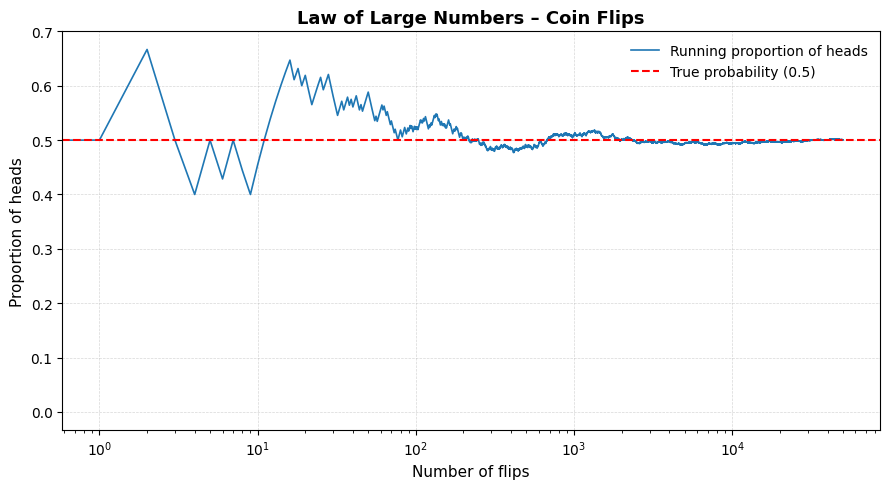

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

def simulate_coin_flips(n_flips: int) -> np.ndarray:
  return rng.integers(low=0, high=2, size=n_flips)

def cumulative_head_proportions(flips: np.ndarray) -> np.ndarray:
  cumulative_heads = np.cumsum(flips)
  counts = np.arange(1, len(flips) + 1)
  return cumulative_heads / counts

n_flips = 50_000
flips = simulate_coin_flips(n_flips)
cum_props = cumulative_head_proportions(flips)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(cum_props, linewidth=1.2, label="Running proportion of heads")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5, label="True probability (0.5)")

ax.set_xlabel("Number of flips", fontsize=11)
ax.set_ylabel("Proportion of heads", fontsize=11)
ax.set_title("Law of Large Numbers – Coin Flips", fontsize=13, fontweight="bold")

ax.set_xscale("log")  # optional: log scale on x to see early behavior
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

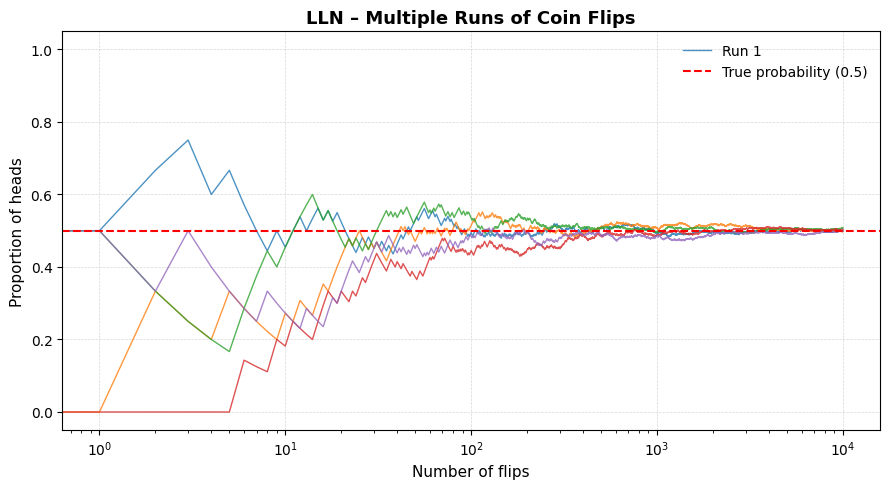

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

n_flips = 10_000
num_runs = 5

for i in range(num_runs):
    flips = simulate_coin_flips(n_flips)
    cum_props = cumulative_head_proportions(flips)
    ax.plot(cum_props, linewidth=1.0, alpha=0.8, label=f"Run {i+1}" if i == 0 else None)

ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5, label="True probability (0.5)")

ax.set_xlabel("Number of flips", fontsize=11)
ax.set_ylabel("Proportion of heads", fontsize=11)
ax.set_title("LLN – Multiple Runs of Coin Flips", fontsize=13, fontweight="bold")
ax.set_xscale("log")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

# Reflection (after code)

## As the n approched to 50,000, the proboblity of getting heads got extremly close to true probobliy of 1/2.
- This behaviour describes that the law of large numbers can imporve the sampling error between the sample and the population, in other words having a large amount of smaple of population can siginificalty reduce the samplting error, as a result getting close the true probobality of X.
- I was surpirsed, how at first the running proportion was fliping around the true proboblity and later as the n approched to 50,000 it become very close to true proboblity.  

# Central Limit Therom
- The "Central Limit Theorem" is a cornerstone of statistics, where as the sample size (n) increases in the CLT, the distribution of the sample mean approaches a normal distribution, the variablity of the sample means decreases, and the accuracy of estimating the population mean imporves.
- The kind of random variable it is talking about are a sufficiently large sample size of the original population, beacuse as the distribution of sample means approaches a noraml distribution, regardless of the shape of the original population distribution. This is true as long as the underlying random variables are independent and identically distributed with a finite mean and variance.
- As the sample size (n) increase in CLT, the distribution of the sample means becomes more and more like a normal distribution, regardless of the shape of the original population distribution. The shpae of the distribution of the sample means becomes more "bell-shaped" and resembles the normal distribution.



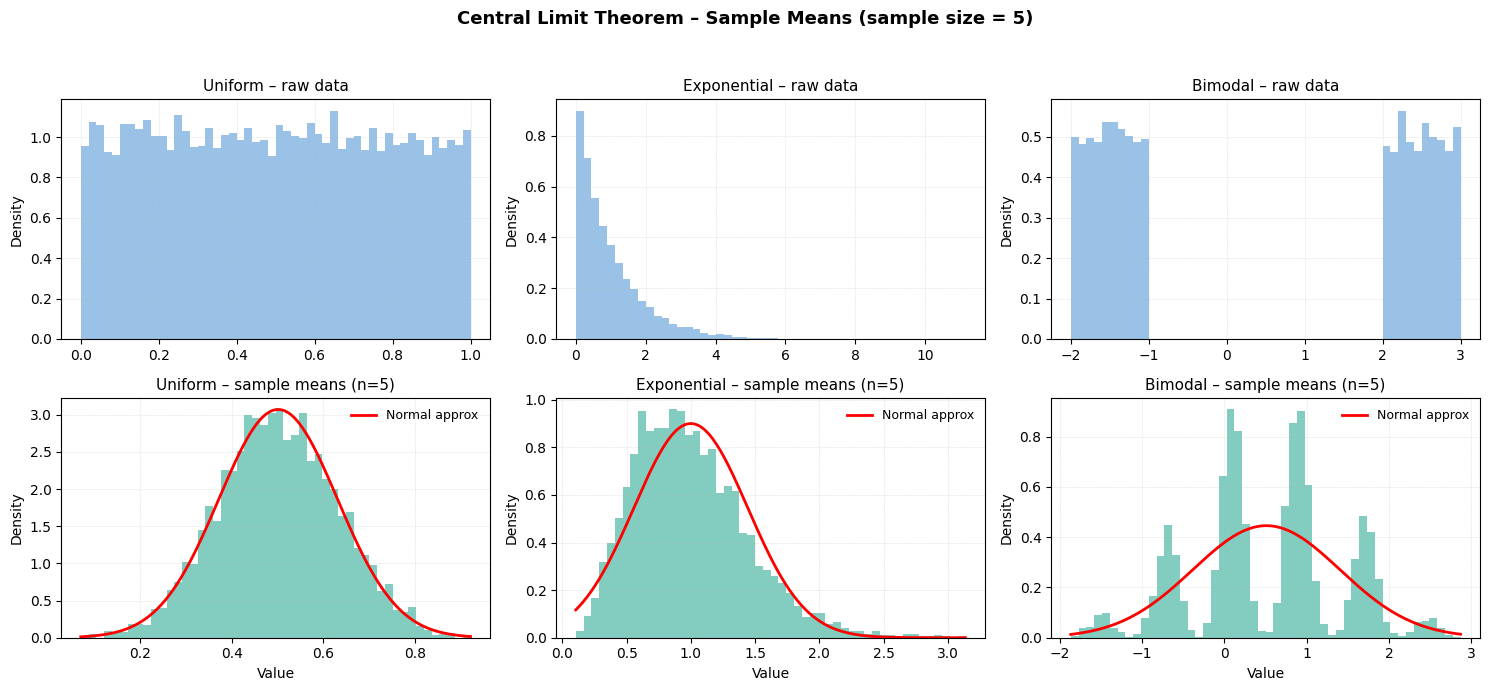

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(seed=42)

def draw_samples(dist: str, n_samples: int, sample_size: int) -> np.ndarray:
  if dist == "uniform":
    return rng.uniform(0, 1, size=(n_samples, sample_size))
  elif dist == "exponential":
    return rng.exponential(scale=1.0, size=(n_samples, sample_size))
  elif dist == "bimodal":
    modes = rng.integers(0, 2, size=(n_samples, sample_size))
    samples = rng.uniform(low=0.0, high=1.0, size=(n_samples, sample_size))
    samples[modes == 0] -= 2.0
    samples[modes == 1] += 2.0
    return samples
  else:
    raise ValueError(f"Unknown distribution: {dist}")

def sample_means_for_dist(dist: str, n_samples: int, sample_size: int) -> np.ndarray:
  data = draw_samples(dist, n_samples=n_samples, sample_size=sample_size)
  return data.mean(axis=1)

n_samples = 5000
sample_size = 5

distributions = ["uniform", "exponential", "bimodal"]

fig, axes = plt.subplots(2, len(distributions), figsize=(5 * len(distributions), 7))

for i, dist in enumerate(distributions):
    # Draw raw data (for one big batch) to show its shape
    raw = draw_samples(dist, n_samples=1, sample_size=10_000).ravel()

    # Compute sample means
    means = sample_means_for_dist(dist, n_samples=n_samples, sample_size=sample_size)

    # --- Top row: raw data histogram ---
    ax_raw = axes[0, i]
    ax_raw.hist(raw, bins=50, density=True, alpha=0.7, color="#6fa8dc", edgecolor="none")
    ax_raw.set_title(f"{dist.capitalize()} – raw data", fontsize=11)
    ax_raw.set_ylabel("Density")
    ax_raw.grid(True, linestyle="--", linewidth=0.4, alpha=0.4)

    # --- Bottom row: sample means histogram + normal fit ---
    ax_mean = axes[1, i]
    ax_mean.hist(means, bins=50, density=True, alpha=0.7, color="#4db8a4", edgecolor="none")

    # Fit a normal using empirical mean & std of the sample means
    mu_hat = means.mean()
    sigma_hat = means.std(ddof=1)
    xs = np.linspace(means.min(), means.max(), 200)
    ax_mean.plot(xs, norm.pdf(xs, loc=mu_hat, scale=sigma_hat),
                 color="red", linewidth=2.0, label="Normal approx")

    ax_mean.set_title(f"{dist.capitalize()} – sample means (n={sample_size})", fontsize=11)
    ax_mean.set_xlabel("Value")
    ax_mean.set_ylabel("Density")
    ax_mean.grid(True, linestyle="--", linewidth=0.4, alpha=0.4)
    ax_mean.legend(frameon=False, fontsize=9)

plt.suptitle(f"Central Limit Theorem – Sample Means (sample size = {sample_size})",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Reflection (after coding)

- Regardless of the original population distribution, as sample means approaches a normal distribution, the variability of the sample means decreases, and the accuracy of estimating the population mean improves.
- When sample size reduced to 5 the sample mean still remained close to normal distribution despite of such a small sample size. For 100 sample size the sample mean become close to perfect normal distribution.
- In Central Limited Theorem under certain condition, the distribution of the sum or average of these random variables approaches a normal distribution as the number of vairables increases, regardless of the shape of original population distribution. As n approaches infinity, the distribution of the normalised sum approaches a standard normal distribution, which has a mean of 0 and a variance of 1. I f the sample size increase in the CLT, the distribution of the smaple means becomes more and more like a normal distribution, regarless of the shape of the original population distribution.
- One practical implication would be that machine learning algorithm love a normal distribution and they do their best when it's normally shaped which hard find in real world conditions.

# Confidence Interval Simulation
- Simlulation demnonstrates that "95% confidence" refers to the process, not a specific interval.
- It means that in the long run, 95% of the intervals generated by this method will capture the true values.
- CI are notoriously easy to misinterpret becuase their technical defination is higly counter-intuitive. Most common errors invole treating them as a measure of probability for a specific result, rather than a measure of a repeated process.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

rng = np.random.default_rng(seed=42)

def simulate_ci_coverage(
    mu: float = 0.0,
    sigma: float = 1.0,
    sample_size: int = 30,
    n_experiments: int = 1000,
    confidence: float = 0.95,
):
    alphas = 1 - confidence
    t_crit = t.ppf(1 - alphas/2, df=sample_size - 1)

    intervals = []
    contains_true = 0

    for _ in range(n_experiments):
      sample = rng.normal(loc=mu, scale=sigma, size=sample_size)
      xbar = sample.mean()
      s = sample.std(ddof=1)

      margin = t_crit * s / np.sqrt(sample_size)
      lower = xbar - margin
      upper = xbar + margin

      intervals.append((lower, upper))
      if lower <= mu <= upper:
        contains_true += 1

    coverage_rate = contains_true / n_experiments
    return np.array(intervals), coverage_rate

true_mu = 0.0
true_sigma = 1.0
smaple_size = 30
n_experiments = 500

intervals, coverage = simulate_ci_coverage(
    mu=true_mu,
    sigma=true_sigma,
    sample_size=smaple_size,
    n_experiments=n_experiments,
    confidence=0.95
)

print(f"Estimated coverage: {coverage:.3f} (target: 0.95)")

Estimated coverage: 0.934 (target: 0.95)


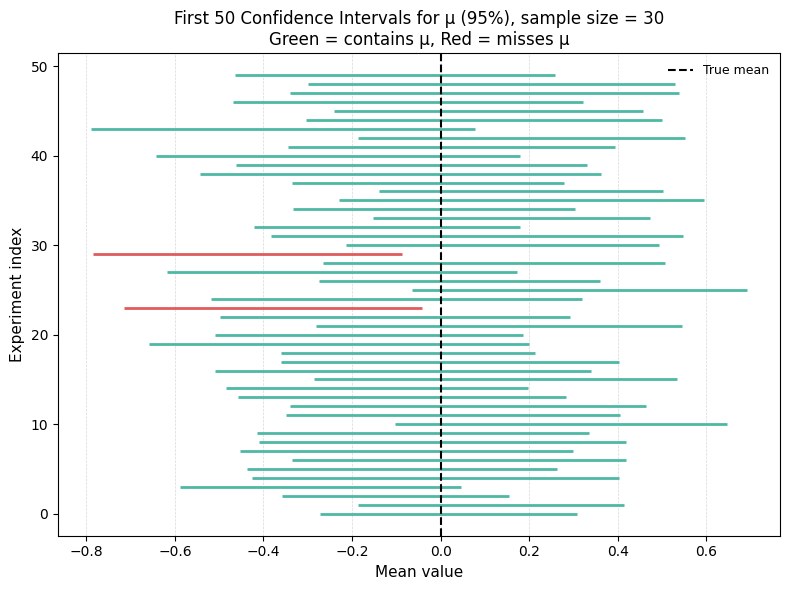

In [ ]:
# Visualize the first, say, 50 intervals

k = min(50, len(intervals))
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(k):
    lower, upper = intervals[i]
    contains = (lower <= true_mu <= upper)
    color = "#4db8a4" if contains else "#e05c5c"

    ax.hlines(y=i, xmin=lower, xmax=upper, colors=color, linewidth=2)

ax.axvline(true_mu, color="black", linestyle="--", linewidth=1.5, label="True mean")

ax.set_xlabel("Mean value", fontsize=11)
ax.set_ylabel("Experiment index", fontsize=11)
ax.set_title(
    f"First {k} Confidence Intervals for μ (95%), "
    f"sample size = {smaple_size}\nGreen = contains μ, Red = misses μ",
    fontsize=12
)
ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

# Confidence Interval for Sorting Runtime
## Here I connect sorting benchmark with statistics & CIs.

I will:
- Fix one algorithm and one input size.
- Run the algorithm many times, collecting runtime measurements.
- Treat the runtimes as a sample and build a 95% confidence interval for the **mean runtime**.

- Using a normal distribution model for the sample mean runtime is resonable when we have many samples.
- Given my data and this standard method, pluasible values for the long-run average runtime lie between L and U seconds, and if I re-run this whole timing experiment many times, about 95% of similary constructed interval would cover that true average.



# MergeSort from benchmark experiment

In [15]:
def merge(arr, left, mid, right):
  n1 = mid - left + 1
  n2 = right - mid

  L = [0] * n1
  R = [0] * n2

  for i in range(n1):
    L[i] = arr[left + i]

  for j in range(n2):
    R[j] = arr[mid + 1 + j]

  i = 0
  j = 0
  k = left

  while i < n1 and j < n2:
    if L[i] <= R[j]:
      arr[k] = L[i]
      i += 1
    else:
      arr[k] = R[j]
      j += 1
    k += 1

  while i < n1:
    arr[k] = L[i]
    i += 1
    k += 1

  while j < n2:
    arr[k] = R[j]
    j += 1
    k += 1

def mergeSort(arr, left, right):
  if left < right:
    mid = (left + right) // 2
    mergeSort(arr, left, mid)
    mergeSort(arr, mid + 1, right)
    merge(arr, left, mid, right)

# QuickSort from benchmark experiment

In [2]:
def partition(arr, low, high):
  pivot = arr[high]
  i = low - 1
  for j in range(low, high):
    if arr[j] < pivot:
      i += 1
      swap(arr, i, j)

  swap(arr, i + 1, high)
  return i + 1

def swap(arr, i, j):
  arr[i], arr[j] = arr[j], arr[i]

def quicksort(arr, low, high):
  if low < high:
    pi = partition(arr, low, high)

    quicksort(arr, low, pi - 1)
    quicksort(arr, pi + 1, high)

if __name__ == "__main__":
  arr = [90, 98, 56, 23, 87, 295, 564, 0, -9568]
  quicksort(arr, 0, len(arr) - 1)
  print(arr)

[-9568, 0, 23, 56, 87, 90, 98, 295, 564]


# Collecting runtime samples

In [20]:
import timeit
import numpy as np

algo = mergeSort
algo_name = 'mergeSort'
n = 10_000
pattern = "random"
n_runs = 100

def gen_random_list(n: list):
  import random
  return [random.randint(0, 10**6) for _ in range(n)]

def single_run_time(fn, data):
  # The original quicksort function expects (arr, low, high).
  # We need to pass 0 and len(data) - 1 for low and high.
  stmt = "_fn(_data.copy(), 0, len(_data) - 1)"
  timer = timeit.Timer(stmt, globals={"_fn": fn, "_data": data})
  return timer.timeit(number=1)

times = []
for i in range(n_runs):
  arr = gen_random_list(n)
  t = single_run_time(algo, arr)
  times.append(t)
  if (i + 1) % 10 == 0:
    print(f"Run {i+1:3d}/{n_runs} -> {t:.6f} s")

times = np.array(times)
print(f"\nSample mean runtimes: {times.mean():.6f} s")
print(f"Sample std dev: {times.std(ddof=1):.6f} s")

Run  10/100 -> 0.041309 s
Run  20/100 -> 0.032783 s
Run  30/100 -> 0.031964 s
Run  40/100 -> 0.033073 s
Run  50/100 -> 0.031816 s
Run  60/100 -> 0.033238 s
Run  70/100 -> 0.032972 s
Run  80/100 -> 0.031873 s
Run  90/100 -> 0.033100 s
Run 100/100 -> 0.032443 s

Sample mean runtimes: 0.037019 s
Sample std dev: 0.017234 s


# A 95% CI for mean runtime

In [21]:
from scipy.stats import t
def mena_runtime_ci(times: np.ndarray, confidence: float = 0.95):
  n = len(times)
  xbar = times.mean()
  s = times.std(ddof=1)
  alpha = 1 - confidence
  t_crit = t.ppf(1 - alpha/2, df=n - 1)
  margin = t_crit * s / np.sqrt(n)
  lower, upper = xbar - margin, xbar + margin
  return (xbar, lower, upper)

mean_rt, lower, upper = mena_runtime_ci(times, confidence=0.95)
print(f"Mean runtime estimate: {mean_rt:.6f} s")
print(f"95% CI for mean: [{lower:.6f}, {upper:.6g}] s")

Mean runtime estimate: 0.037019 s
95% CI for mean: [0.033600, 0.0404387] s


# Sample distribution and CI

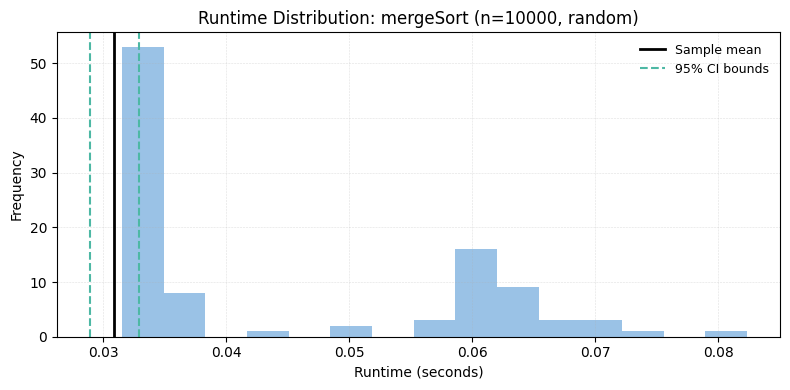

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(times, bins=15, alpha=0.7, color="#6fa8dc", edgecolor="none")
ax.axvline(mean_rt, color="black", linestyle="-", linewidth=2, label="Sample mean")
ax.axvline(lower, color="#4db8a4", linestyle="--", linewidth=1.5, label="95% CI bounds")
ax.axvline(upper, color="#4db8a4", linestyle="--", linewidth=1.5)

ax.set_xlabel("Runtime (seconds)")
ax.set_ylabel("Frequency")
ax.set_title(f"Runtime Distribution: {algo_name} (n={n}, {pattern})")
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.4)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

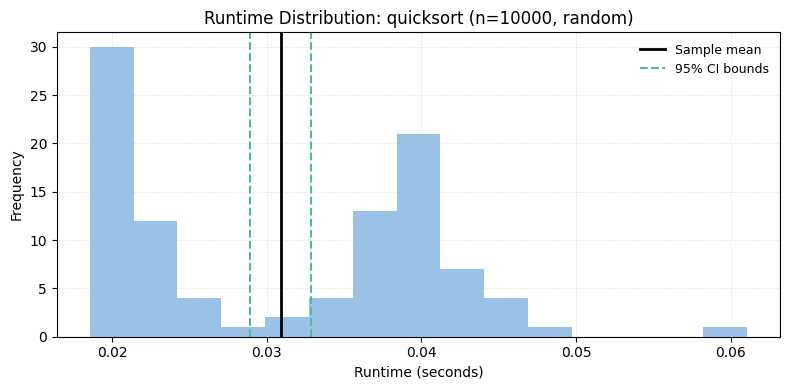

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(times, bins=15, alpha=0.7, color="#6fa8dc", edgecolor="none")
ax.axvline(mean_rt, color="black", linestyle="-", linewidth=2, label="Sample mean")
ax.axvline(lower, color="#4db8a4", linestyle="--", linewidth=1.5, label="95% CI bounds")
ax.axvline(upper, color="#4db8a4", linestyle="--", linewidth=1.5)

ax.set_xlabel("Runtime (seconds)")
ax.set_ylabel("Frequency")
ax.set_title(f"Runtime Distribution: {algo_name} (n={n}, {pattern})")
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.4)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

# Reflection

Based on the CI I computed:

- My beest estimate of the mean runtime  is: 0.030880s for **MergeSort** and for 0.023761s **QuickSort**.
- The 95% confidence interval is: for [0.033600, 0.0404387]s **MergeSort** and for [0.021828, 0.0256932]s **QuickSort**.

In words:

> If I repeated this whole experiment many times (drawing fresh random arrays, timing mergesort and quicksort, and building a new CI each time), than about 95% of those intervals would contain the **true** mean runtime of mergesort and quicksort for random arrays of size n = 10,000.

This is a statement about the **procedure**, not about the probability that this particular interval contains the true value.

- For MergeSort the interval felt wide relative to the mean, it's quite variables across runs. For QuickSort the interval felt tight relative to the mean, the runtime is stable.

- I could make the inverval narrower by more controlled enviourment and a fewer background processes.

- This helps in a real Ml/DS setting, when comparing two algorithms, I could compare their mean runtimes **with uncertainity** instead of just single numbers.